# Reproducing existing figures from the new foraging database

This notebook shows how to **reproduce two figures we already had** — but now sourcing
the data from the **new foraging parquet database** (the `session` / `trial` tables on public
S3) through the DuckDB query helpers, instead of the old `han_pipeline.get_session_table()`
return loop.

1. **Weekly session counts over time, split by curriculum type.**
   Reproduces the session-count plot from
   [`demo_curriculum.ipynb`](https://github.com/AllenNeuralDynamics/aind-dynamic-foraging-population-analysis/blob/han_dev/notebooks/demo_curriculum.ipynb),
   reading `curriculum_name` straight out of our `session_table`.

2. **Single-session choice/reward raster.**
   Uses `plot_foraging_session` from
   [`aind-dynamic-foraging-basic-analysis`](https://github.com/AllenNeuralDynamics/aind-dynamic-foraging-basic-analysis)
   to draw a few example sessions at the final curriculum stages with low side bias
   (`|bias_naive| < 0.05`, `finished_trials > 500`,
   `current_stage_actual IN ('STAGE_FINAL', 'GRADUATED')`), feeding it the trial columns
   from our `trial_table`.

> The helper functions here are written **inline for demonstration** — they are not part of
> the production API. The two production reads we lean on are `query.select_sessions` and
> `query.fetch_trials` (plus raw DuckDB for the session-level aggregation).

The basic-analysis package is `pip install -e`'d under `/root/aind-dynamic-foraging-basic-analysis`,
so you can edit `plot_foraging_session.py` there and re-run these cells to see the effect.

In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from aind_dynamic_foraging_database import (
    SESSION_DB,        # s3:// path to the flat session_table.parquet (public, no creds)
    select_sessions,   # filter the session table -> DataFrame
    fetch_trials,      # pull those sessions' trials, session metadata joined on
)

plt.rcParams.update({"font.size": 11})
print("session table:", SESSION_DB)

session table: s3://aind-scratch-data/aind-dynamic-foraging-cache/session_table.parquet


## 1. Weekly session counts over time, by curriculum type

The reference notebook does this from `get_session_table()`. We instead read the same
columns (`subject_id`, `session_date`, `curriculum_name`) from our `session_table` with a
one-line DuckDB query — no NWB loading, no pipeline dependency.

In [2]:
def load_session_curriculum(session_db=SESSION_DB):
    """Read (subject_id, session_date, curriculum_name) from the database session table.

    Returns a tidy frame with `session_date` parsed to datetime and `curriculum`
    collapsed to the major curriculum types (off-curriculum sessions -> "Off-curriculum").
    """
    df = duckdb.sql(f"""
        SELECT subject_id, session_date, curriculum_name
        FROM read_parquet('{session_db}')
    """).df()
    df["session_date"] = pd.to_datetime(df["session_date"], errors="coerce")
    df = df.dropna(subset=["session_date"])
    df["curriculum"] = df["curriculum_name"].map(_major_curriculum)
    return df


def _major_curriculum(name):
    """Collapse the raw curriculum_name into the handful of major types (robust to variants)."""
    if name is None or (isinstance(name, float) and np.isnan(name)) or str(name) == "None":
        return "Off-curriculum"
    n = str(name).lower().replace(" ", "")
    if "uncoupled" in n:
        return "Uncoupled Without Baiting" if "withoutbaiting" in n else "Uncoupled Baiting"
    if "coupled" in n:
        return "Coupled Baiting"
    return "Off-curriculum"


sessions = load_session_curriculum()
print(len(sessions), "sessions")
sessions["curriculum"].value_counts()

23867 sessions


curriculum
Uncoupled Baiting            12858
Off-curriculum                6800
Uncoupled Without Baiting     3858
Coupled Baiting                351
Name: count, dtype: int64

In [3]:
def plot_session_counts_over_time(
    df,
    time_bin="W",
    group_by="curriculum",
    group_order=None,
    group_color=None,
    ax=None,
):
    """Stacked bar of session counts per `time_bin`, split by `group_by`.

    Adapted from `plot_session_counts_over_time` in demo_curriculum.ipynb; defaults to
    weekly bins (`time_bin="W"`).
    """
    counts = (
        df.groupby([pd.Grouper(key="session_date", freq=time_bin), group_by])
        .size()
        .unstack(fill_value=0)
    )
    if group_order is not None:
        group_order = [g for g in group_order if g in counts.columns]
        counts = counts[group_order]

    if ax is None:
        fig, ax = plt.subplots(figsize=(11, 4), dpi=120)
    counts.plot(
        kind="bar", stacked=True, ax=ax, width=1.0,
        **({} if group_color is None else {"color": group_color}),
    )
    ax.set_xlabel("Date")
    ax.set_ylabel(f"Number of sessions per {time_bin}")

    # Sparse year-month ticks
    step = max(1, len(counts) // 12)
    ax.set_xticks(range(0, len(counts), step))
    ax.set_xticklabels(counts.index[::step].strftime("%Y-%m"), rotation=45, ha="right")
    ax.legend(title="Curriculum", fontsize=9, title_fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    return ax, counts

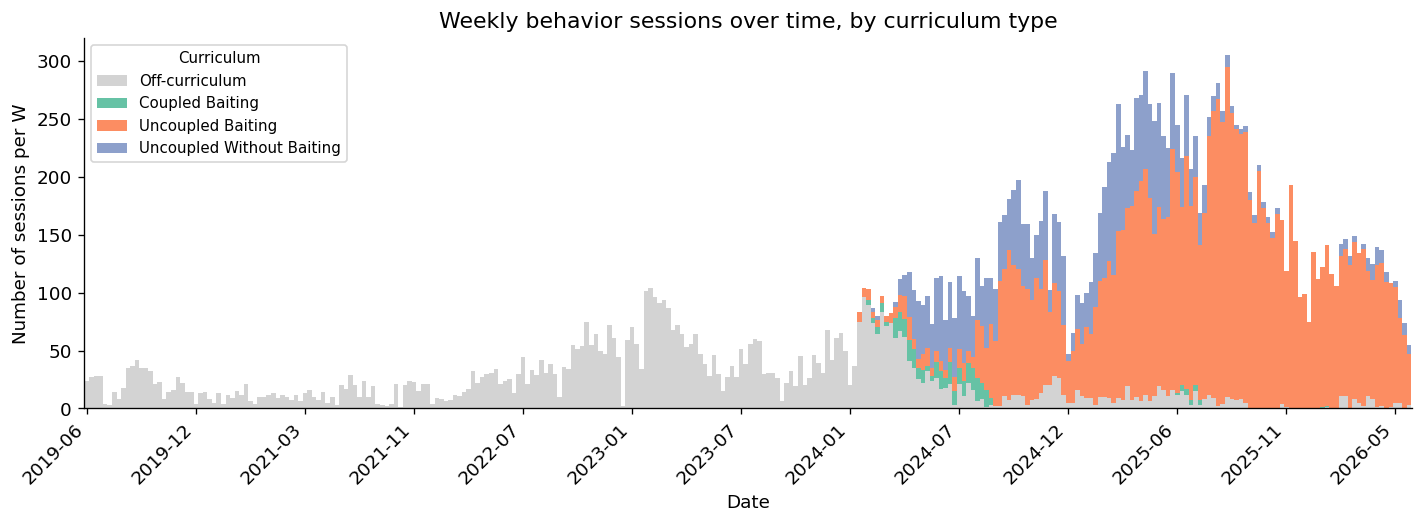

weeks: 292 | total sessions: 23867


In [4]:
order = ["Off-curriculum", "Coupled Baiting", "Uncoupled Baiting", "Uncoupled Without Baiting"]
cmap = matplotlib.colormaps["Set2"]
colors = ["lightgray"] + [cmap(i) for i in range(3)]

fig, ax = plt.subplots(figsize=(12, 4.5), dpi=120)
ax, weekly = plot_session_counts_over_time(
    sessions, time_bin="W", group_order=order, group_color=colors, ax=ax,
)
ax.set_title("Weekly behavior sessions over time, by curriculum type")
plt.tight_layout()
plt.show()

print("weeks:", len(weekly), "| total sessions:", int(weekly.values.sum()))

## 2. Single-session choice/reward raster (`plot_foraging_session`)

`plot_foraging_session` wants exactly three arrays per session, which map straight onto our
default trial columns:

| arg | source column | encoding |
|---|---|---|
| `choice_history` | `animal_response` | 0 = left, 1 = right, **2 → np.nan** (ignored) |
| `reward_history` | `earned_reward` | 0 = unrewarded, 1 = rewarded |
| `p_reward` | `reward_probabilityL`, `reward_probabilityR` | stacked `(2, n_trials)` |

First pick a few final-stage, low-bias sessions (small `|bias_naive|`), then pull their trials.

In [5]:
good = select_sessions(
    where=(
        "ABS(bias_naive) < 0.05 AND finished_trials > 500 "
        "AND current_stage_actual IN ('STAGE_FINAL', 'GRADUATED')"  # final curriculum stages only
    ),
    columns=["task", "bias_naive", "finished_trials", "current_stage_actual"],
)
print(len(good), "final-stage sessions with |bias_naive| < 0.05 and finished_trials > 500")

# A few examples spanning different subjects for variety
examples = good.drop_duplicates("subject_id").head(4).reset_index(drop=True)
examples[["subject_id", "session_date", "task", "bias_naive",
          "finished_trials", "current_stage_actual"]]

521 final-stage sessions with |bias_naive| < 0.05 and finished_trials > 500


,subject_id,session_date,task,bias_naive,finished_trials,current_stage_actual
0,697929,2024-03-07,Coupled Baiting,0.038760,516.0,STAGE_FINAL
1,703548,2024-03-06,Uncoupled Baiting,0.045283,530.0,STAGE_FINAL
2,711039,2024-08-28,Uncoupled Without Baiting,0.028571,595.0,STAGE_FINAL
3,714116,2024-07-25,Uncoupled Without Baiting,0.007246,552.0,GRADUATED


In [6]:
# One scoped read pulls all example sessions' trials (default choice/reward columns).
trials = fetch_trials(examples)
print(len(trials), "trial rows across", trials["session_id"].nunique(), "sessions")
trials.head(3)

2345 trial rows across 4 sessions


,subject_id,session_date,session_id,trial,task,bias_naive,finished_trials,current_stage_actual,animal_response,earned_reward,reward_probabilityL,reward_probabilityR
0,697929,2024-03-07,697929_2024-03-07_84701,0.0,Coupled Baiting,0.03876,516.0,STAGE_FINAL,1.0,False,0.385714,0.064286
1,697929,2024-03-07,697929_2024-03-07_84701,1.0,Coupled Baiting,0.03876,516.0,STAGE_FINAL,1.0,False,0.385714,0.064286
2,697929,2024-03-07,697929_2024-03-07_84701,2.0,Coupled Baiting,0.03876,516.0,STAGE_FINAL,2.0,False,0.385714,0.064286


In [7]:
def plot_session_from_trials(g, **kwargs):
    """Draw one session with plot_foraging_session, given its trial-table rows `g`."""
    from aind_dynamic_foraging_basic_analysis.plot.plot_foraging_session import (
        plot_foraging_session,
    )
    g = g.sort_values("trial")
    choice = g["animal_response"].astype(float).to_numpy()
    choice[choice == 2] = np.nan                      # ignored trials
    reward = g["earned_reward"].astype(float).to_numpy()
    p_reward = np.vstack([
        g["reward_probabilityL"].astype(float).to_numpy(),
        g["reward_probabilityR"].astype(float).to_numpy(),
    ])
    fig, axes = plot_foraging_session(choice, reward, p_reward, **kwargs)
    meta = g.iloc[0]
    # Left-aligned info text above the axes (matches plot_foraging_session_nwb; the legend
    # sits to the upper-right, so a centered title would collide with it).
    axes[0].text(
        0, 1.05,
        f"{meta['session_id']}  |  {meta['task']}  |  "
        f"bias={meta['bias_naive']:+.3f}, finished={int(meta['finished_trials'])}",
        fontsize=9, transform=axes[0].transAxes,
    )
    return fig, axes

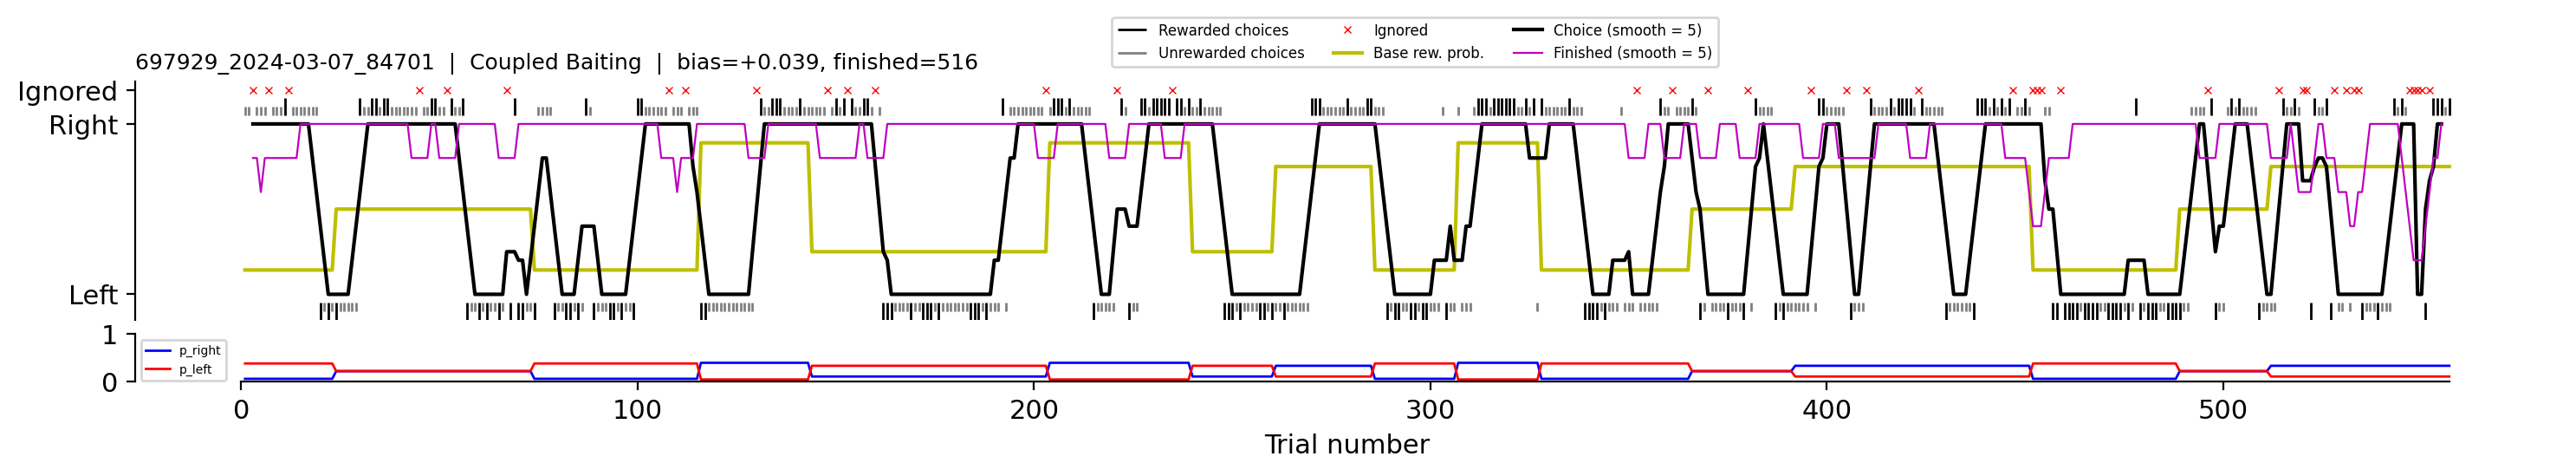

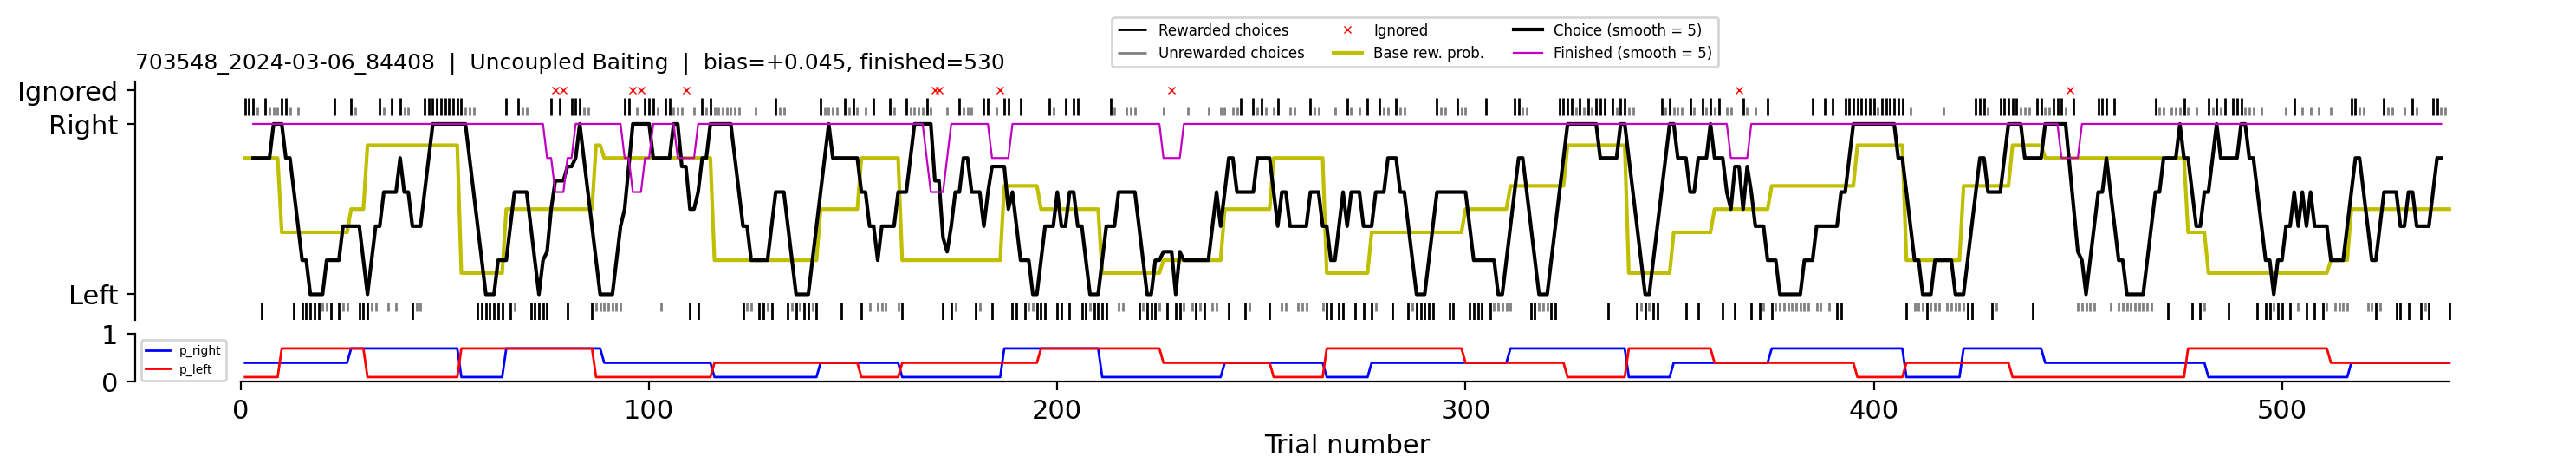

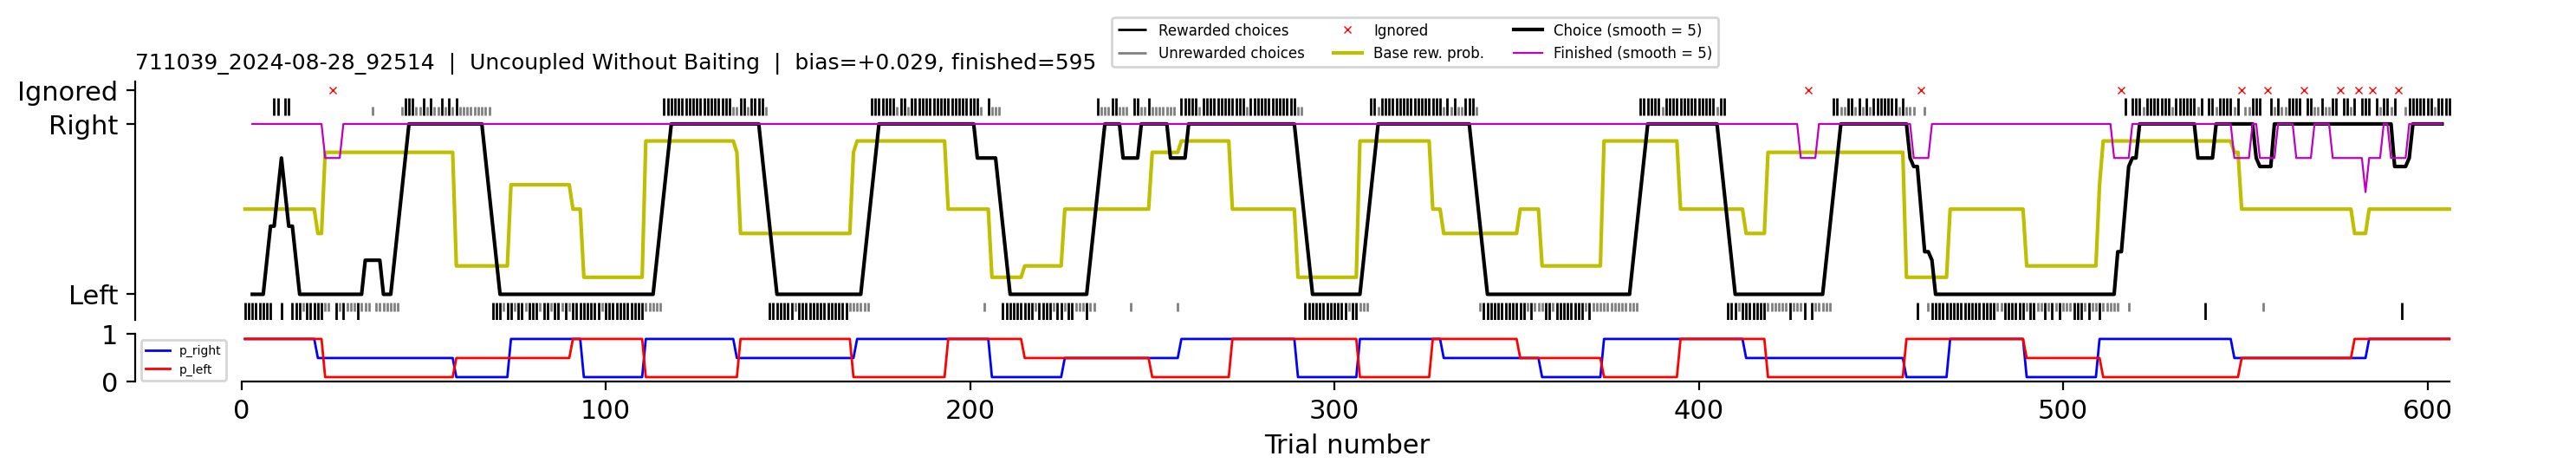

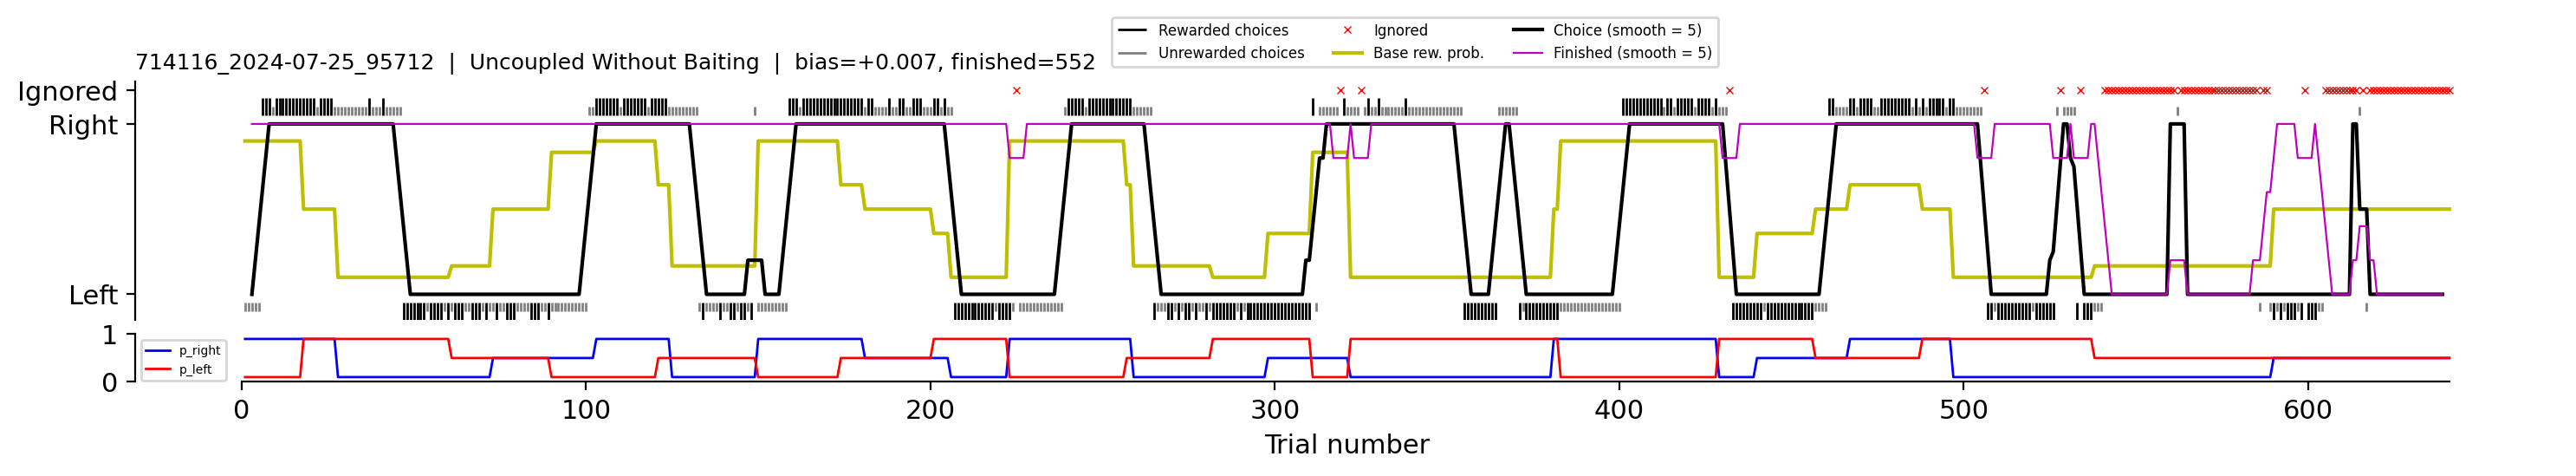

In [8]:
for sid, g in trials.groupby("session_id"):
    fig, axes = plot_session_from_trials(g)
    plt.show()

## 3. Interactive (plotly) versions

The same two views as interactive plotly figures (zoom / pan / hover), from
`aind_dynamic_foraging_basic_analysis`. Each mirrors its matplotlib sibling:

- `plot_foraging_session_plotly` — **trial-based**, mirrors `plot_foraging_session` (§2).
- `plot_session_in_time_plotly` — **time-based**, mirrors `plot_session_scroller`; it plots
  licks / rewards / go cues and the reward-probability band in real time. It starts zoomed
  to the first go cue (like the scroller's default window) — **drag the rangeslider at the
  bottom to scrub through the session**.

> Interactive plotly output renders in Jupyter / nbviewer (it does not render on GitHub).

In [9]:
import plotly.io as pio
from aind_dynamic_foraging_basic_analysis import plot_foraging_session_plotly

pio.renderers.default = "notebook_connected"  # embed plotly.js (renders in Jupyter/nbviewer)

# Reuse the first example session's trials (fetched in §2)
ex = examples.iloc[0]
g = trials[trials["session_id"] == ex["_session_id"]].sort_values("trial")
choice = g["animal_response"].astype(float).to_numpy()
choice[choice == 2] = np.nan
fig = plot_foraging_session_plotly(
    choice_history=choice,
    reward_history=g["earned_reward"].astype(float).to_numpy(),
    p_reward=np.vstack([g["reward_probabilityL"].astype(float).to_numpy(),
                        g["reward_probabilityR"].astype(float).to_numpy()]),
)
fig.update_layout(title=dict(text=f"{ex['_session_id']}  |  {ex['task']}  |  bias={ex['bias_naive']:+.3f}", x=0, xanchor="left", y=0.98, yanchor="top"))
fig.show(config={"scrollZoom": True})

In [10]:
from aind_dynamic_foraging_database import fetch_events
from aind_dynamic_foraging_basic_analysis import plot_session_in_time_plotly

one = examples.iloc[[2]]  # a single-session "sessions" frame
# Events drive the licks / rewards / go cues; trials drive the reward-probability band.
ev = fetch_events(one)
trg = fetch_trials(
    one,
    columns=["trial", "animal_response", "goCue_start_time",
             "reward_probabilityL", "reward_probabilityR"],
).sort_values("trial")
fig = plot_session_in_time_plotly(ev, df_trials=trg, title=ex["_session_id"])
fig.show(config={"scrollZoom": True})

## 4. Lifetime of an example "good" mouse

Both plotly functions concatenate **multiple sessions horizontally** when given session
labels — a thick vertical line marks each session boundary and the smoothed traces reset
per session:

- `plot_foraging_session_plotly` takes a per-trial `session_id=` array (the trial axis runs
  0…N\u2081, then 0…N\u2082, …).
- `plot_session_in_time_plotly` reads the `session_id` **column** of `df_events` (sessions
  laid end-to-end in time).

Here we plot the **whole lifetime** of one example well-performing mouse, selected as a mouse
that graduated within 10 sessions and kept finish-rate > 0.9 and foraging-eff > 0.7 at the
late (`STAGE_FINAL` / `GRADUATED`) stages.

The **trial-based** plot shows the whole lifetime. The **time-based** raster of a whole
lifetime would embed tens of thousands of events, so below it is shown on a representative
window (the graduation sessions) — the function itself accepts any number of sessions.

In [11]:
# Find well-performing mice: graduated within 10 sessions (date order) + good late stages
good_mice = duckdb.sql(f"""
    WITH s AS (
        SELECT subject_id, session_date, current_stage_actual, finished_rate, foraging_eff,
               ROW_NUMBER() OVER (PARTITION BY subject_id ORDER BY session_date) AS rank,
               COUNT(*)     OVER (PARTITION BY subject_id) AS n_sessions
        FROM read_parquet('{SESSION_DB}')
    ),
    grad AS (SELECT subject_id, MIN(rank) AS grad_rank FROM s
             WHERE current_stage_actual = 'GRADUATED' GROUP BY subject_id),
    late AS (SELECT subject_id, AVG(finished_rate) AS fr, AVG(foraging_eff) AS eff
             FROM s WHERE current_stage_actual IN ('STAGE_FINAL', 'GRADUATED') GROUP BY subject_id)
    SELECT g.subject_id, g.grad_rank, MAX(s.n_sessions) AS n_sessions
    FROM grad g JOIN late l USING (subject_id) JOIN s USING (subject_id)
    WHERE g.grad_rank <= 10 AND l.fr > 0.9 AND l.eff > 0.7
    GROUP BY g.subject_id, g.grad_rank
    ORDER BY n_sessions
""").df()
example_mouse = str(good_mice["subject_id"].iloc[0])   # the shortest such lifetime
print(f"{len(good_mice)} candidate mice; plotting lifetime of {example_mouse}")

# Its whole lifetime, in date order (early stages -> graduation)
life = select_sessions(subjects=[example_mouse],
                       columns=["current_stage_actual", "finished_rate", "foraging_eff"])
life[["session_date", "current_stage_actual", "finished_rate", "foraging_eff"]]

4 candidate mice; plotting lifetime of 802253


,session_date,current_stage_actual,finished_rate,foraging_eff
0,2025-09-02,STAGE_1_WARMUP,0.729084,0.580601
1,2025-09-03,STAGE_1,0.907713,0.663885
2,2025-09-04,STAGE_2,0.986154,0.678086
3,2025-09-05,STAGE_2,0.973684,0.766740
4,2025-09-08,STAGE_3,0.998016,0.673369
5,2025-09-09,STAGE_FINAL,0.996875,0.763969
6,2025-09-10,STAGE_FINAL,1.000000,0.659047
7,2025-09-11,STAGE_FINAL,0.948235,0.777707
8,2025-09-12,STAGE_FINAL,0.993976,0.727905
9,2025-09-16,GRADUATED,0.997685,0.699439


In [12]:
# Trial-based lifetime: concatenate every session's trials; session_id marks the boundaries
lt = fetch_trials(life).sort_values(["session_date", "trial"])
choice = lt["animal_response"].astype(float).to_numpy()
choice[choice == 2] = np.nan
fig = plot_foraging_session_plotly(
    choice_history=choice,
    reward_history=lt["earned_reward"].astype(float).to_numpy(),
    p_reward=np.vstack([lt["reward_probabilityL"].astype(float).to_numpy(),
                        lt["reward_probabilityR"].astype(float).to_numpy()]),
    session_id=lt["session_id"].to_numpy(),
)
fig.update_layout(title=dict(text=f"{example_mouse} \u2014 lifetime ({len(life)} sessions, {len(lt)} trials)", x=0, xanchor="left", y=0.98, yanchor="top"))
fig.show(config={"scrollZoom": True})

In [13]:
# Time-based over several sessions. A whole-lifetime raster embeds a lot of points, so we
# show a representative window here (the graduation sessions); pass all of `life` to plot the
# full lifetime live.
life_window = life.tail(4)
lev = fetch_events(life_window)
ltrg = fetch_trials(
    life_window,
    columns=["trial", "animal_response", "goCue_start_time",
             "reward_probabilityL", "reward_probabilityR"],
).sort_values(["session_date", "trial"])
fig = plot_session_in_time_plotly(
    lev, df_trials=ltrg, title=f"{example_mouse} \u2014 {len(life_window)} sessions (graduation)"
)
fig.show(config={"scrollZoom": True})